# Plot Generation for UPI Fraud Detection

This notebook generates the core evaluation plots for the Real-Time UPI Fraud Detection System.

The plots explain how the anomaly detection model separates normal and fraudulent UPI transactions, how the optimized threshold performs, and how precision-recall changes across thresholds.

## 1. Imports and Project Paths

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import auc, confusion_matrix, precision_recall_curve


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

FINAL_PREDICTIONS_PATH = PROCESSED_DATA_DIR / "final_predictions.csv"
THRESHOLD_RESULTS_PATH = PROCESSED_DATA_DIR / "threshold_evaluation_results.csv"
THRESHOLD_METADATA_PATH = MODELS_DIR / "threshold_metadata.pkl"
FEATURE_DATA_PATH = PROCESSED_DATA_DIR / "upi_transactions_with_features.csv"

ANOMALY_DISTRIBUTION_PATH = FIGURES_DIR / "anomaly_score_distribution.png"
CONFUSION_MATRIX_PATH = FIGURES_DIR / "confusion_matrix.png"
PRECISION_RECALL_CURVE_PATH = FIGURES_DIR / "precision_recall_curve.png"
THRESHOLD_TUNING_GRAPH_PATH = FIGURES_DIR / "threshold_tuning_graph.png"
FRAUD_RATE_BY_HOUR_PATH = FIGURES_DIR / "fraud_rate_by_hour.png"
AMOUNT_ANOMALY_SCATTER_PATH = FIGURES_DIR / "amount_vs_anomaly_score.png"
FEATURE_MEAN_COMPARISON_PATH = FIGURES_DIR / "feature_mean_comparison.png"
ALERT_OUTCOME_BREAKDOWN_PATH = FIGURES_DIR / "alert_outcome_breakdown.png"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("default")

## 2. Load Evaluation Artifacts

In [2]:
def require_file(path: Path) -> None:
    """Raise a clear error if a required pipeline artifact is missing."""
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")


def load_plot_inputs() -> tuple[pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    """Load final predictions, threshold search results, and selected threshold metadata."""
    for path in [FINAL_PREDICTIONS_PATH, THRESHOLD_RESULTS_PATH, THRESHOLD_METADATA_PATH]:
        require_file(path)

    predictions = pd.read_csv(FINAL_PREDICTIONS_PATH)
    threshold_results = pd.read_csv(THRESHOLD_RESULTS_PATH)
    threshold_metadata = joblib.load(THRESHOLD_METADATA_PATH)
    return predictions, threshold_results, threshold_metadata


predictions, threshold_results, threshold_metadata = load_plot_inputs()

print(f"Predictions shape: {predictions.shape}")
print(f"Threshold candidates: {threshold_results.shape[0]}")
print(f"Best threshold: {threshold_metadata['best_threshold']:.6f}")
predictions.head()

Predictions shape: (10000, 6)
Threshold candidates: 200
Best threshold: 0.009042


,decision_score,anomaly_score,default_prediction,is_suspicious_default,is_fraud,is_suspicious_optimized
0,0.113136,-0.113136,1,0,0,0
1,0.103800,-0.103800,1,0,0,0
2,0.096125,-0.096125,1,0,0,0
3,0.106898,-0.106898,1,0,0,0
4,0.087459,-0.087459,1,0,0,0


## 3. Validate Plot Inputs

In [3]:
def validate_plot_inputs(predictions: pd.DataFrame, threshold_results: pd.DataFrame) -> None:
    """Validate that all required columns exist before plotting."""
    required_prediction_columns = {"anomaly_score", "is_fraud", "is_suspicious_optimized"}
    required_threshold_columns = {"threshold", "f1_score"}

    missing_prediction_columns = required_prediction_columns.difference(predictions.columns)
    missing_threshold_columns = required_threshold_columns.difference(threshold_results.columns)

    if missing_prediction_columns:
        raise ValueError(f"Missing prediction columns: {sorted(missing_prediction_columns)}")
    if missing_threshold_columns:
        raise ValueError(f"Missing threshold columns: {sorted(missing_threshold_columns)}")


validate_plot_inputs(predictions, threshold_results)
print("Plot input validation passed.")

Plot input validation passed.


## 4. Anomaly Score Distribution

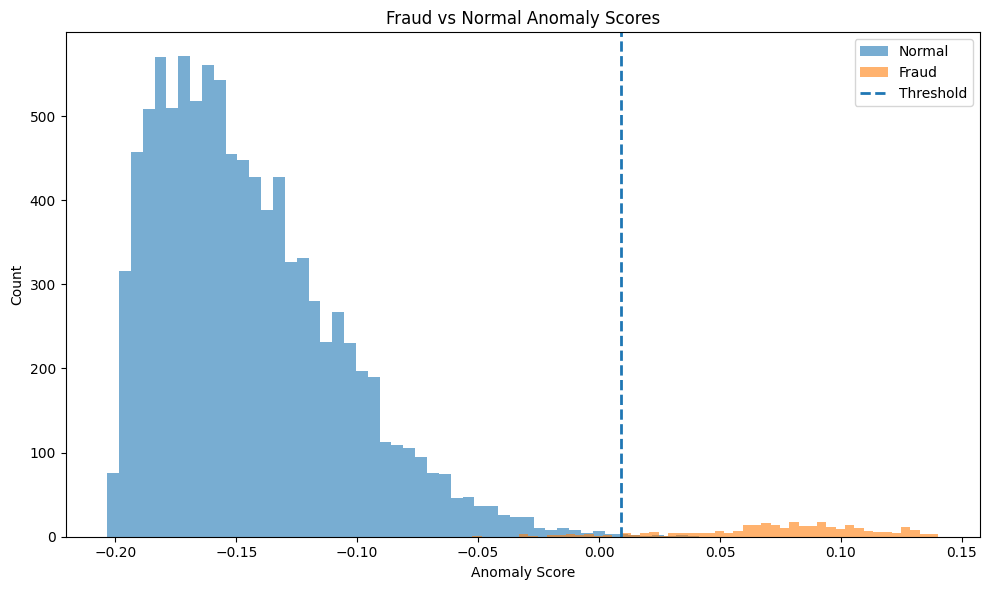

Saved anomaly score distribution: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\reports\figures\anomaly_score_distribution.png


In [4]:
def plot_anomaly_score_distribution(
    predictions: pd.DataFrame,
    threshold: float,
    output_path: Path,
) -> None:
    """Plot fraud and normal anomaly score distributions with the chosen threshold."""
    normal_scores = predictions.loc[predictions["is_fraud"] == 0, "anomaly_score"]
    fraud_scores = predictions.loc[predictions["is_fraud"] == 1, "anomaly_score"]

    plt.figure(figsize=(10, 6))
    plt.hist(normal_scores, bins=50, alpha=0.6, label="Normal", color="tab:blue")
    plt.hist(fraud_scores, bins=50, alpha=0.6, label="Fraud", color="tab:orange")
    plt.axvline(threshold, color="tab:blue", linestyle="--", linewidth=2, label="Threshold")
    plt.title("Fraud vs Normal Anomaly Scores")
    plt.xlabel("Anomaly Score")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


best_threshold = float(threshold_metadata["best_threshold"])
plot_anomaly_score_distribution(predictions, best_threshold, ANOMALY_DISTRIBUTION_PATH)
print(f"Saved anomaly score distribution: {ANOMALY_DISTRIBUTION_PATH}")

## 5. Confusion Matrix

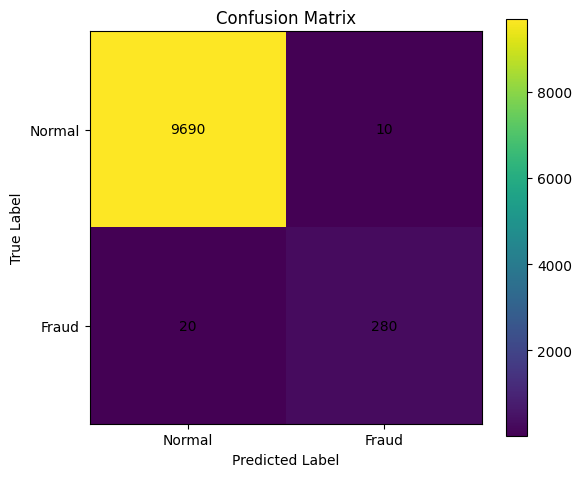

[[9690   10]
 [  20  280]]
Saved confusion matrix: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\reports\figures\confusion_matrix.png


In [5]:
def plot_confusion_matrix(predictions: pd.DataFrame, output_path: Path) -> np.ndarray:
    """Plot the optimized-threshold confusion matrix."""
    matrix = confusion_matrix(predictions["is_fraud"], predictions["is_suspicious_optimized"])

    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(matrix, cmap="viridis")
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Normal", "Fraud"])
    ax.set_yticklabels(["Normal", "Fraud"])

    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            ax.text(column_index, row_index, matrix[row_index, column_index], ha="center", va="center", color="black")

    fig.colorbar(image, ax=ax)
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.show()
    return matrix


confusion = plot_confusion_matrix(predictions, CONFUSION_MATRIX_PATH)
print(confusion)
print(f"Saved confusion matrix: {CONFUSION_MATRIX_PATH}")

## 6. Precision-Recall Curve

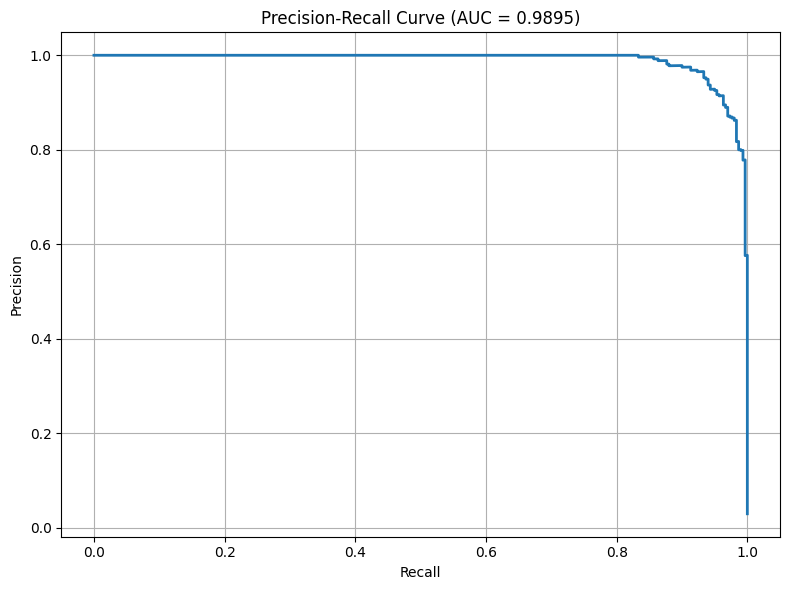

AUPRC: 0.9895
Saved precision-recall curve: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\reports\figures\precision_recall_curve.png


In [6]:
def plot_precision_recall_curve(predictions: pd.DataFrame, output_path: Path) -> float:
    """Plot the precision-recall curve using anomaly scores."""
    precision, recall, _ = precision_recall_curve(predictions["is_fraud"], predictions["anomaly_score"])
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, linewidth=2)
    plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()
    return float(pr_auc)


pr_auc = plot_precision_recall_curve(predictions, PRECISION_RECALL_CURVE_PATH)
print(f"AUPRC: {pr_auc:.4f}")
print(f"Saved precision-recall curve: {PRECISION_RECALL_CURVE_PATH}")

## 7. Threshold Tuning Graph

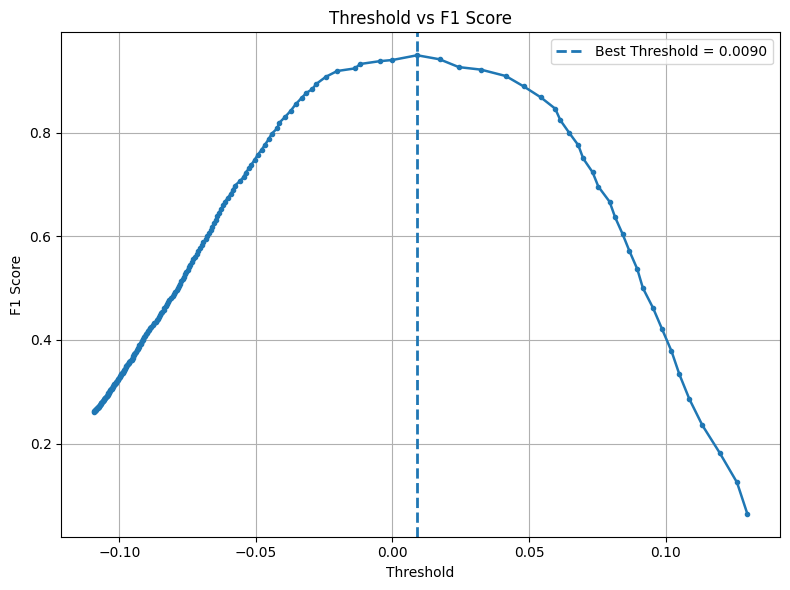

Saved threshold tuning graph: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\reports\figures\threshold_tuning_graph.png


In [7]:
def plot_threshold_tuning_graph(
    threshold_results: pd.DataFrame,
    threshold: float,
    output_path: Path,
) -> None:
    """Plot F1-score across thresholds and mark the selected best threshold."""
    ordered_results = threshold_results.sort_values("threshold")

    plt.figure(figsize=(8, 6))
    plt.plot(
        ordered_results["threshold"],
        ordered_results["f1_score"],
        marker="o",
        markersize=3,
        linewidth=1.8,
    )
    plt.axvline(threshold, color="tab:blue", linestyle="--", linewidth=2, label=f"Best Threshold = {threshold:.4f}")
    plt.title("Threshold vs F1 Score")
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


plot_threshold_tuning_graph(threshold_results, best_threshold, THRESHOLD_TUNING_GRAPH_PATH)
print(f"Saved threshold tuning graph: {THRESHOLD_TUNING_GRAPH_PATH}")

## 8. Additional Project-Relevant Plots

In [8]:
def load_engineered_features(path: Path) -> pd.DataFrame:
    """Load engineered transactions for feature-level plots."""
    require_file(path)
    return pd.read_csv(path, parse_dates=["timestamp"])


engineered_features = load_engineered_features(FEATURE_DATA_PATH)
plot_dataset = engineered_features.reset_index(drop=True).join(
    predictions[["anomaly_score", "is_suspicious_optimized"]].reset_index(drop=True)
)

plot_dataset.head()

,transaction_id,timestamp,sender_account_id,receiver_account_id,amount,location_pincode,transaction_type,is_fraud,hour_of_day,day_of_week,is_first_time_receiver,transaction_value,amount_vs_user_avg,velocity_last_10min,anomaly_score,is_suspicious_optimized
0,TXN_005083,2024-01-01 00:00:00,ACC_1001,RCV_4436,1487.51,560001,Merchant,0,0,0,1,1487.51,1.000000,1.0,-0.113136,0
1,TXN_008283,2024-01-01 00:50:00,ACC_4572,RCV_7208,2711.60,560001,P2P,0,0,0,1,2711.60,1.219036,1.0,-0.103800,0
2,TXN_002316,2024-01-01 01:05:00,ACC_4271,RCV_5491,497.85,560001,P2P,0,1,0,1,497.85,0.337527,1.0,-0.096125,0
3,TXN_003674,2024-01-01 01:10:00,ACC_4711,RCV_3991,3050.08,560001,P2P,0,1,0,1,3050.08,1.551246,1.0,-0.106898,0
4,TXN_007006,2024-01-01 01:20:00,ACC_4038,RCV_4270,5436.65,700001,P2P,0,1,0,1,5436.65,1.000000,1.0,-0.087459,0


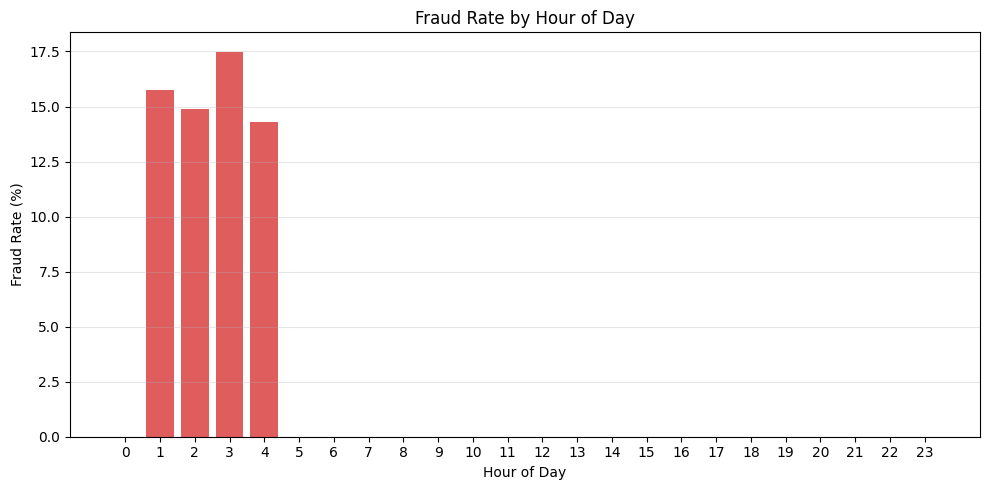

Saved fraud rate by hour plot: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\reports\figures\fraud_rate_by_hour.png


In [9]:
def plot_fraud_rate_by_hour(plot_dataset: pd.DataFrame, output_path: Path) -> None:
    """Plot observed fraud rate by transaction hour."""
    hourly_fraud_rate = plot_dataset.groupby("hour_of_day")["is_fraud"].mean().mul(100)

    plt.figure(figsize=(10, 5))
    plt.bar(hourly_fraud_rate.index, hourly_fraud_rate.values, color="tab:red", alpha=0.75)
    plt.title("Fraud Rate by Hour of Day")
    plt.xlabel("Hour of Day")
    plt.ylabel("Fraud Rate (%)")
    plt.xticks(range(0, 24))
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


plot_fraud_rate_by_hour(plot_dataset, FRAUD_RATE_BY_HOUR_PATH)
print(f"Saved fraud rate by hour plot: {FRAUD_RATE_BY_HOUR_PATH}")

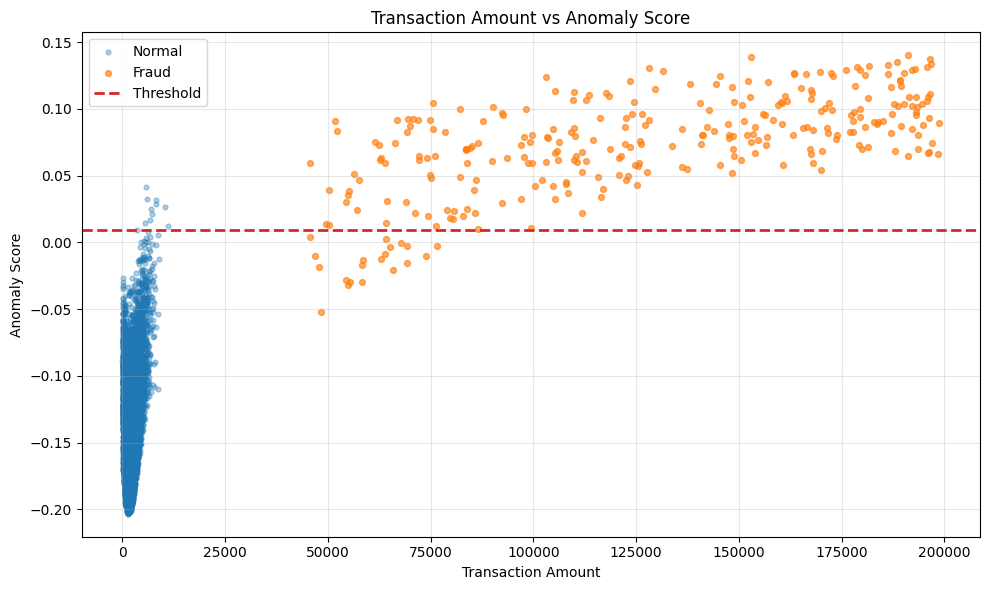

Saved amount vs anomaly score plot: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\reports\figures\amount_vs_anomaly_score.png


In [10]:
def plot_amount_vs_anomaly_score(plot_dataset: pd.DataFrame, threshold: float, output_path: Path) -> None:
    """Plot transaction amount against anomaly score, colored by true label."""
    normal = plot_dataset[plot_dataset["is_fraud"] == 0]
    fraud = plot_dataset[plot_dataset["is_fraud"] == 1]

    plt.figure(figsize=(10, 6))
    plt.scatter(normal["amount"], normal["anomaly_score"], s=12, alpha=0.35, label="Normal", color="tab:blue")
    plt.scatter(fraud["amount"], fraud["anomaly_score"], s=18, alpha=0.65, label="Fraud", color="tab:orange")
    plt.axhline(threshold, color="tab:red", linestyle="--", linewidth=2, label="Threshold")
    plt.title("Transaction Amount vs Anomaly Score")
    plt.xlabel("Transaction Amount")
    plt.ylabel("Anomaly Score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


plot_amount_vs_anomaly_score(plot_dataset, best_threshold, AMOUNT_ANOMALY_SCATTER_PATH)
print(f"Saved amount vs anomaly score plot: {AMOUNT_ANOMALY_SCATTER_PATH}")

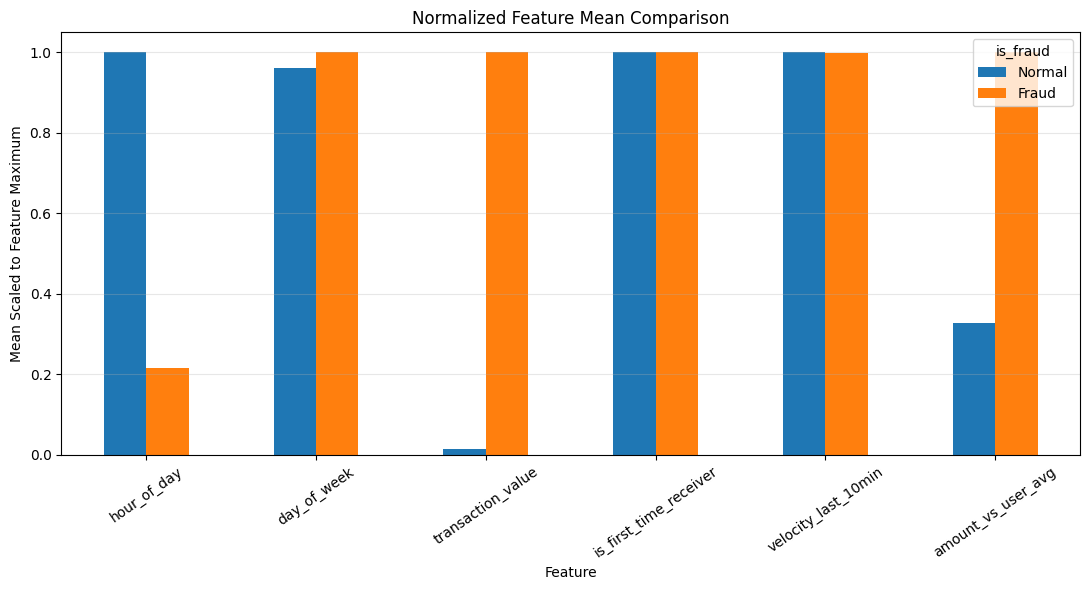

Saved feature mean comparison plot: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\reports\figures\feature_mean_comparison.png


In [11]:
def plot_feature_mean_comparison(plot_dataset: pd.DataFrame, output_path: Path) -> None:
    """Compare normalized feature means for normal and fraud transactions."""
    feature_columns = [
        "hour_of_day",
        "day_of_week",
        "transaction_value",
        "is_first_time_receiver",
        "velocity_last_10min",
        "amount_vs_user_avg",
    ]
    means = plot_dataset.groupby("is_fraud")[feature_columns].mean().rename(index={0: "Normal", 1: "Fraud"})
    normalized_means = means / means.max(axis=0).replace(0, np.nan)

    ax = normalized_means.T.plot(kind="bar", figsize=(11, 6), color=["tab:blue", "tab:orange"])
    ax.set_title("Normalized Feature Mean Comparison")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Mean Scaled to Feature Maximum")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


plot_feature_mean_comparison(plot_dataset, FEATURE_MEAN_COMPARISON_PATH)
print(f"Saved feature mean comparison plot: {FEATURE_MEAN_COMPARISON_PATH}")

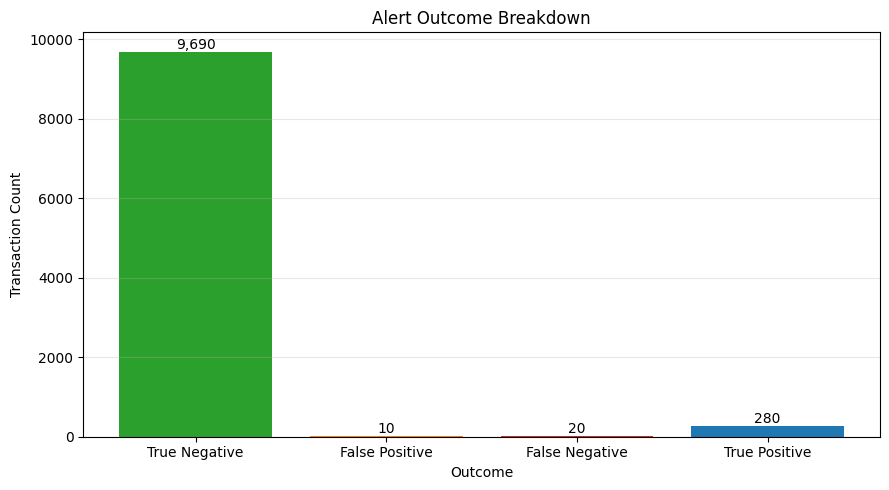

Saved alert outcome breakdown plot: C:\Users\Prompt\Documents\Real-Time-UPI-Fraud-Detection-System_Notebook\Real-Time-UPI-Fraud-Detection-System\reports\figures\alert_outcome_breakdown.png


In [12]:
def plot_alert_outcome_breakdown(predictions: pd.DataFrame, output_path: Path) -> None:
    """Plot true/false positive and true/false negative counts."""
    true_labels = predictions["is_fraud"]
    predicted_labels = predictions["is_suspicious_optimized"]
    outcomes = pd.Series(
        np.select(
            [
                (true_labels == 0) & (predicted_labels == 0),
                (true_labels == 0) & (predicted_labels == 1),
                (true_labels == 1) & (predicted_labels == 0),
                (true_labels == 1) & (predicted_labels == 1),
            ],
            ["True Negative", "False Positive", "False Negative", "True Positive"],
            default="Unknown",
        )
    ).value_counts().reindex(["True Negative", "False Positive", "False Negative", "True Positive"], fill_value=0)

    plt.figure(figsize=(9, 5))
    bars = plt.bar(outcomes.index, outcomes.values, color=["tab:green", "tab:orange", "tab:red", "tab:blue"])
    plt.title("Alert Outcome Breakdown")
    plt.xlabel("Outcome")
    plt.ylabel("Transaction Count")
    plt.grid(axis="y", alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f"{height:,.0f}", ha="center", va="bottom")

    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()


plot_alert_outcome_breakdown(predictions, ALERT_OUTCOME_BREAKDOWN_PATH)
print(f"Saved alert outcome breakdown plot: {ALERT_OUTCOME_BREAKDOWN_PATH}")

## 9. Generated Plot Files

Generated files:

- `reports/figures/anomaly_score_distribution.png`
- `reports/figures/confusion_matrix.png`
- `reports/figures/precision_recall_curve.png`
- `reports/figures/threshold_tuning_graph.png`
- `reports/figures/fraud_rate_by_hour.png`
- `reports/figures/amount_vs_anomaly_score.png`
- `reports/figures/feature_mean_comparison.png`
- `reports/figures/alert_outcome_breakdown.png`